<a href="https://colab.research.google.com/github/JOk3r01001/Pipeline-approach-for-fracture-classification-using-YOLO-and-Keras/blob/main/YOLOundersampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import json
from google.colab import drive


#Připojení Google Disku do prostředí Colab pro přístup k souborům
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
import random

# KONFIGURACE CEST
BASE_PATH = "/content/drive/MyDrive/BK2.0/FracAtlas2"
FRACTURED_DIR = os.path.join(BASE_PATH, "images/Fractured")
NON_FRACTURED_DIR = os.path.join(BASE_PATH, "images/Non_fractured")
LABELS_DIR = os.path.join(BASE_PATH, "Annotations/YOLO_Segmentation")

LOCAL_DATA = "/content/yolo_data"
PROJECT_OUT = "/content/drive/MyDrive/YOLO_undersample"

os.makedirs(PROJECT_OUT, exist_ok=True)

# Příprava adresářové struktury
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(LOCAL_DATA, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(LOCAL_DATA, split, 'labels'), exist_ok=True)

# NAČTENÍ DAT A PŘÍPRAVA LABELŮ PRO STRATIFIKACI (1 pro zlomeninu, 0 pro zdravou)
f_imgs = [(f, "Fractured", 1) for f in os.listdir(FRACTURED_DIR) if f.endswith('.jpg')]
nf_imgs = [(f, "Non_fractured", 0) for f in os.listdir(NON_FRACTURED_DIR) if f.endswith('.jpg')]

all_imgs = f_imgs + nf_imgs

labels = [x[2] for x in all_imgs]

# STRATIFIKOVANÝ SPLIT (80/10/10)
train_list, temp_list = train_test_split(all_imgs,test_size=0.2,random_state=42,stratify=labels)

temp_labels = [x[2] for x in temp_list]

#rozdělení zbytku na 50/50
val_list, test_list = train_test_split(temp_list,test_size=0.5,random_state=42,stratify=temp_labels)

# Distribuce splitu + export
def process_split(data_list, split_name):
    print(f" Zpracovávám {split_name} data (počet: {len(data_list)})...")

    # Seznam pro uložení do CSV
    csv_data = []

    for img_name, folder, label in data_list:
        # A) Kopírování snímků
        src_img = os.path.join(BASE_PATH, "images", folder, img_name)
        dst_img = os.path.join(LOCAL_DATA, split_name, 'images', img_name)
        shutil.copy(src_img, dst_img)

        # B) Zpracování anotací
        label_name = img_name.replace('.jpg', '.txt')
        src_label = os.path.join(LABELS_DIR, label_name)
        dst_label = os.path.join(LOCAL_DATA, split_name, 'labels', label_name)

        if os.path.exists(src_label):
            shutil.copy(src_label, dst_label)
        else:
            open(dst_label, 'w').close() # Prázdný soubor pro zdravé kosti

        # Přidání do seznamu pro export
        csv_data.append({'img_name': img_name, 'class': folder, 'label': label})

    # C) Uložení CSV souboru pro Keras
    df = pd.DataFrame(csv_data)
    csv_filename = os.path.join(PROJECT_OUT, f"universal_{split_name}_split.csv")
    df.to_csv(csv_filename, index=False)
    print(f"  -> Seznam uložen do: {csv_filename}")


process_split(train_list, 'train')
process_split(val_list, 'val')
process_split(test_list, 'test')

train_lbl = os.path.join(LOCAL_DATA, 'train', 'labels')
train_img = os.path.join(LOCAL_DATA, 'train', 'images')

# Rozdělení na pozitivní a negativní
positives = []
negatives = []

for lbl in os.listdir(train_lbl):
    if lbl.endswith('.txt'):
        lbl_path = os.path.join(train_lbl, lbl)
        if os.path.getsize(lbl_path) > 0:
            positives.append(os.path.splitext(lbl)[0])
        else:
            negatives.append(os.path.splitext(lbl)[0])

print(f"Před undersamplingem:")
print(f"  Pozitivní: {len(positives)}")
print(f"  Negativní: {len(negatives)}")

# Undersampling poměr (33/67)
target_negatives = len(positives) * 2
random.seed(42)
negatives_to_remove = random.sample(negatives, len(negatives) - target_negatives)

# Odstranění přebytečných negativních vzorků
for stem in negatives_to_remove:
    for ext in ['.jpg']:
        img_path = os.path.join(train_img, f"{stem}{ext}")
        if os.path.exists(img_path):
            os.remove(img_path)
            break
    os.remove(os.path.join(train_lbl, f"{stem}.txt"))

final_imgs = []
for img in os.listdir(train_img):
    if img.endswith('.jpg'):
        stem = os.path.splitext(img)[0]
        lbl_path = os.path.join(train_lbl, f"{stem}.txt")
        label = 1 if os.path.getsize(lbl_path) > 0 else 0
        final_imgs.append({'img_name': img, 'label': label})

final_df = pd.DataFrame(final_imgs)
final_df.to_csv(os.path.join(PROJECT_OUT, 'universal_train_split.csv'), index=False)
print(f"Final train list exported: {len(final_df)} images")




print(f"\nPo undersampleingu:")
print(f"  Pozitivní: {len(positives)}")
print(f"  Negativní: {target_negatives}")
print(f"  Celkem: {len(positives) + target_negatives}")
print(f"  Poměr pozitivních: {len(positives)/(len(positives)+target_negatives)*100:.1f}%")


print("READY TO TRAIN")

 Zpracovávám train data (počet: 3266)...
 Zpracovávám val data (počet: 408)...
 Zpracovávám test data (počet: 409)...
Před undersamplingem:
  Pozitivní: 574
  Negativní: 2692

Po undersampleingu:
  Pozitivní: 574
  Negativní: 1148
  Celkem: 1722
  Poměr pozitivních: 33.3%
READY TO TRAIN


In [ ]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
#YAML konfigurace pro YOLO
yaml_content = f"""
train: {LOCAL_DATA}/train/images
val: {LOCAL_DATA}/val/images
test: {LOCAL_DATA}/test/images
nc: 1
names: ['Fracture']
"""
with open('/content/data.yaml', 'w') as f:
    f.write(yaml_content)

model = YOLO('yolo11s-seg.pt')

model.train(
    data='/content/data.yaml',
    epochs=75,
    patience=20,
    imgsz=640,
    batch=8,
    device=0,
    project=PROJECT_OUT,
    name='frac_atlas_seg_640_usample',
    exist_ok=True,

    optimizer='AdamW',
    lr0=0.0005,
    weight_decay=0.0005,
    cos_lr=True,
    warmup_epochs=5,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.2,
    degrees=15,
    fliplr=0.5,
    flipud=0.0,
    scale=0.3,
    shear=2.0,
    mixup=0.0,


    cache=False,
    workers=2,
    amp=True,
    save=True,
    save_period=10,
    augment=True,
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=frac_atlas_seg_640_usample, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, persp

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78cd734e0950>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,203 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 535.7±203.7 MB/s, size: 15.0 KB)
val: Scanning /content/yolo_data/test/labels... 399 images, 327 backgrounds, 10 corrupt: 100% ━━━━━━━━━━━━ 409/409 613.9it/s 0.7s
val: /content/yolo_data/test/images/IMG0004062.jpg: corrupt JPEG restored and saved
val: /content/yolo_data/test/images/IMG0004076.jpg: ignoring corrupt image/label: image file is truncated (0 bytes not processed)
val: /content/yolo_data/test/images/IMG0004079.jpg: ignoring corrupt image/label: image file is truncated (24 bytes not processed)
val: /content/yolo_data/test/images/IMG0004100.jpg: ignoring corrupt image/label: image file is truncated (15 bytes not processed)
val: /content/yolo_data/test/images/IMG0004142.jpg: ignoring corrupt image/label: image file is truncated (32 bytes not processed)
val: /co

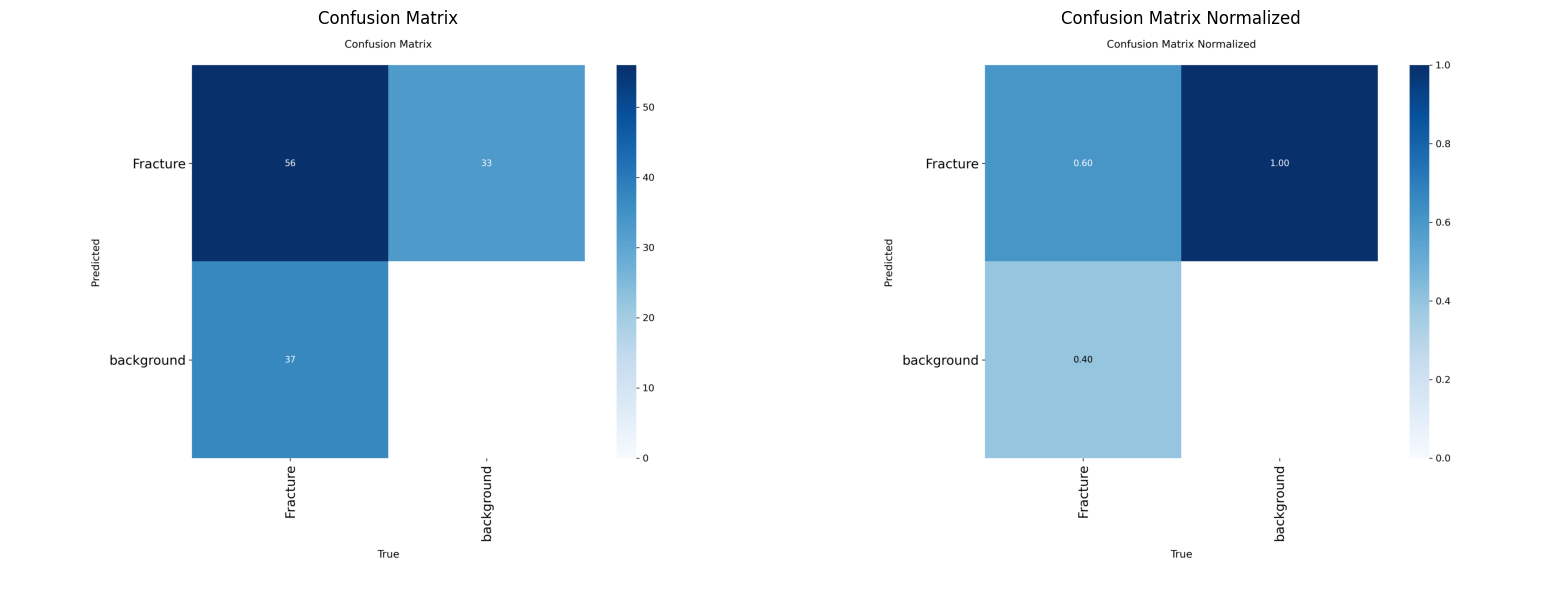

Uloženo v: /content/runs/segment/val


In [ ]:

yaml_content = f"""
train: {LOCAL_DATA}/train/images
val: {LOCAL_DATA}/val/images
test: {LOCAL_DATA}/test/images
nc: 1
names: ['fracture']
"""
with open('/content/data.yaml', 'w') as f:
    f.write(yaml_content)




model_path = '/content/drive/MyDrive/YOLO_undersample/frac_atlas_seg_640_usample/weights/best.pt'
model = YOLO(model_path)



metrics = model.val(data='/content/data.yaml', split='test')


print(f"Přesnost (Precision): {metrics.seg.p[0]:.4f}")
print(f"Citlivost (Recall):    {metrics.seg.r[0]:.4f}")
print(f"mAP50 (Mask):          {metrics.seg.map50:.4f}")
print(f"mAP50-95 (Mask):       {metrics.seg.map:.4f}")

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# CF trainset
cm_path = metrics.save_dir / 'confusion_matrix.png'
cm_normalized_path = metrics.save_dir / 'confusion_matrix_normalized.png'


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(mpimg.imread(cm_path))
axes[0].set_title('Confusion Matrix')
axes[0].axis('off')

axes[1].imshow(mpimg.imread(cm_normalized_path))
axes[1].set_title('Confusion Matrix Normalized')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Uloženo v: {metrics.save_dir}")